validated with LISAAnalysisTools-cuda12x v1.2.0 & fastlisaresponse v1.1.17

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux
from few.utils.constants import Gpc, MRSUN_SI, YRSID_SI
from typing import Optional, Union, Callable
from tqdm import tqdm

use_gpu = True

from stableemrifisher.fisher.fisher import StableEMRIFisher
from stableemrifisher.utils import inner_product

from fastlisaresponse import ResponseWrapper  # Response function 
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
    force_backend = 'cpu'
else:
    pass #let the backend decide for itself.

startup


In [2]:
#waveform class setup
waveform_class = FastSchwarzschildEccentricFlux
waveform_class_kwargs = dict(inspiral_kwargs=dict(err=1e-11,),
                             mode_selector_kwargs=dict(mode_selection_threshold=1e-5))

#waveform generator setup
waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)

#ResponseWrapper setup
ResponseWrapper = ResponseWrapper
tdi_gen ="1st generation"# "2nd generation"#
order = 20  # interpolation order (should not change the result too much)
tdi_kwargs_esa = dict(
    orbits=EqualArmlengthOrbits(), order=order, tdi=tdi_gen, tdi_chan="AE",
)  # could do "AET"
index_lambda = 8
index_beta = 7
# with longer signals we care less about this
t0 = 10000.0  # throw away on both ends when our orbital information is weird
T = 0.1
dt = 10.0

ResponseWrapper_kwargs = dict(
    #waveform_gen=waveform_generator,
    Tobs = T,
    dt = dt,
    index_lambda = index_lambda,
    index_beta = index_beta,
    t0 = t0,
    flip_hx = True,
    is_ecliptic_latitude=False,
    remove_garbage="zero",
    **tdi_kwargs_esa
)

#noise setup
channels = [A1TDISens, E1TDISens]
noise_model = get_sensitivity
noise_kwargs = [{"sens_fn": channel_i} for channel_i in channels]

In [3]:
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       ResponseWrapper=ResponseWrapper, ResponseWrapper_kwargs=ResponseWrapper_kwargs,
                       noise_model=noise_model, noise_kwargs=noise_kwargs, channels=channels,
                      stats_for_nerds = True, use_gpu = use_gpu,
                       T=T, dt=dt,
                      deriv_type='stable')

In [4]:
m1 = 1e6
m2 = 1e1
a = 0.
p0 = 9.5
e0 = 0.4
xI0 = 1.0
dist = 0.1
qS = np.pi/3
phiS = np.pi/4
qK = np.pi/6
phiK = np.pi/8
Phi_phi0 = 1.0
Phi_theta0 = 0.0
Phi_r0 = 0.0

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

emri_kwargs = {"T":T, "dt":dt}

sef.SNRcalc_SEF(*pars_list,**emri_kwargs, use_gpu=use_gpu)

waveform shape: (2, 315581)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.0, 9.5, 0.4, 1.0, 0.1, 1.0471975511965976, 0.7853981633974483, 0.5235987755982988, 0.39269908169872414, 1.0, 0.0, 0.0)


np.float64(237.8375746721959)

Body is not plunging, Fisher should be stable.
waveform shape: (2, 315581)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10.0, 0.0, 9.5, 0.4, 1.0, 0.1, 1.0471975511965976, 0.7853981633974483, 0.5235987755982988, 0.39269908169872414, 1.0, 0.0, 0.0)
Waveform Generated. SNR: 237.8375746721959
calculating stable deltas...
Gamma_ii for m1: 117.5439207338703
Gamma_ii for m1: 117.5439207347031
Gamma_ii for m1: 117.5439207352782
Gamma_ii for m1: 117.54392074920402
Gamma_ii for m1: 117.54392075188987
Gamma_ii for m1: 117.5439215994347
Gamma_ii for m1: 117.54392770681126
Gamma_ii for m1: 117.54395029612209
[np.float64(7.085000344293532e-12), np.float64(4.8927523152766295e-12), np.float64(1.1847327622359223e-10), np.float64(2.2849769890205025e-11), np.float64(7.210452177368134e-09), np.float64(5.1958248143831244e-08), np.float64(1.9217757080529703e-07)]
1


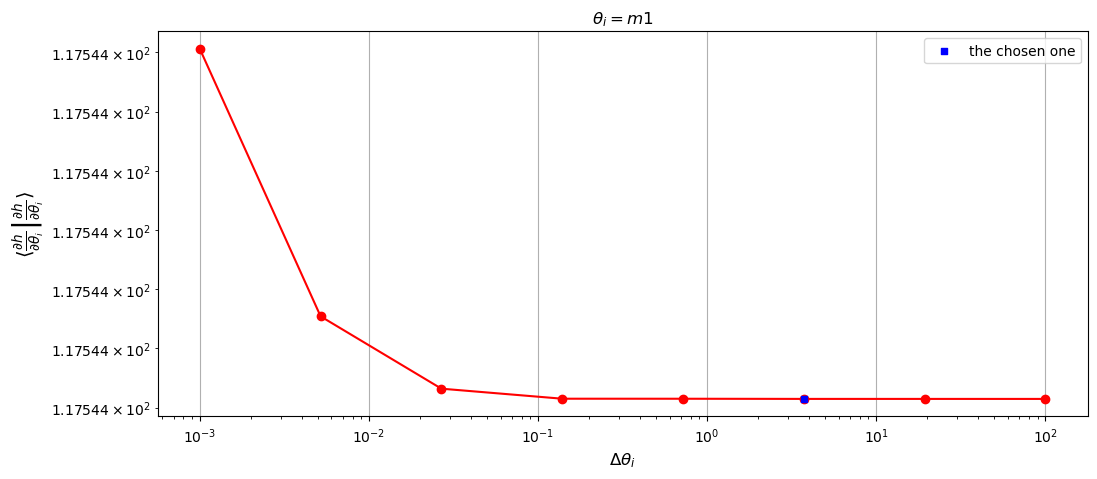

Gamma_ii for m2: 131911056.69511826
Gamma_ii for m2: 131911056.64892384
Gamma_ii for m2: 131911056.6513874
Gamma_ii for m2: 131911056.63890882
Gamma_ii for m2: 131911056.68133233
Gamma_ii for m2: 131911055.8952143
Gamma_ii for m2: 131911060.30618103
Gamma_ii for m2: 131911034.65479088
[np.float64(3.5019368685475734e-10), np.float64(1.867583687123885e-11), np.float64(9.459840159262869e-11), np.float64(3.2160697957566103e-10), np.float64(5.959455219375708e-09), np.float64(3.3438945255378605e-08), np.float64(1.944597752365349e-07)]
1


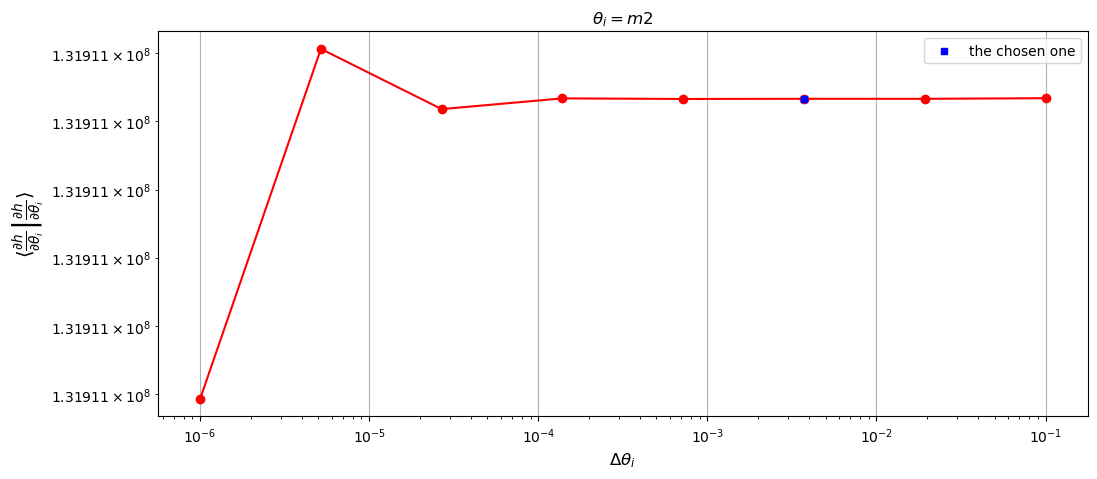

Gamma_ii for p0: 2100668740273.6292
Gamma_ii for p0: 2100669956347.8528
Gamma_ii for p0: 2100670014640.8784
Gamma_ii for p0: 2100670039521.514
Gamma_ii for p0: 2100669177970.8916
Gamma_ii for p0: 2100671006397.3804
Gamma_ii for p0: 2100660595690.2163
Gamma_ii for p0: 2100767662117.5854
[np.float64(5.788982795503175e-07), np.float64(2.7749729956863858e-08), np.float64(1.1844142597337244e-08), np.float64(4.101315101631826e-07), np.float64(8.704011638192006e-07), np.float64(4.955920621075792e-06), np.float64(5.0965382464625845e-05)]
2


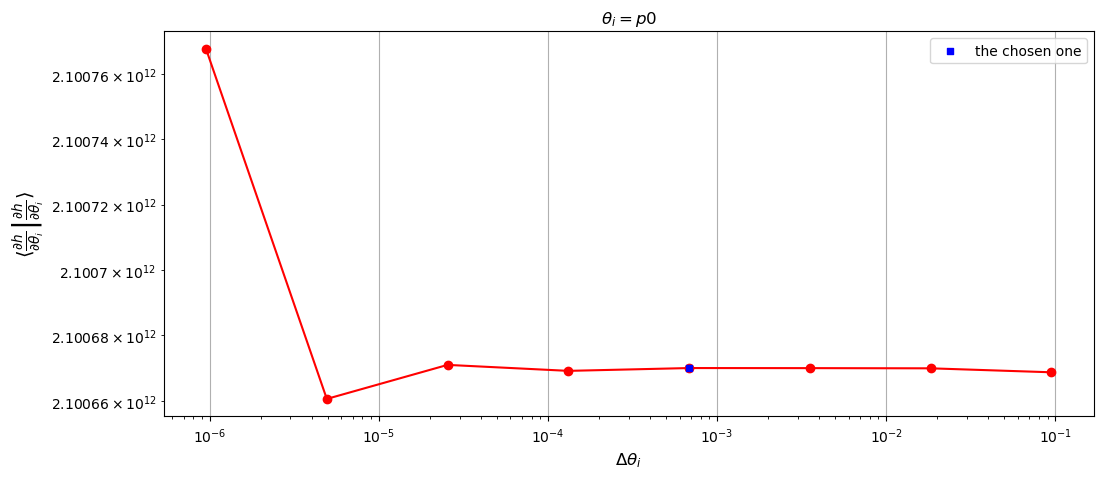

Gamma_ii for e0: 113248542803179.25
Gamma_ii for e0: 113247941283652.4
Gamma_ii for e0: 113247963099334.47
Gamma_ii for e0: 113247977805853.27
Gamma_ii for e0: 113248078262279.61
Gamma_ii for e0: 113247994119203.9
Gamma_ii for e0: 113245792211506.89
Gamma_ii for e0: 113237602908978.86
[np.float64(5.311527256262632e-06), np.float64(1.9263641892935914e-07), np.float64(1.2986120442774817e-07), np.float64(8.870475144937605e-07), np.float64(7.429983758878474e-07), np.float64(1.9443615996814843e-05), np.float64(7.231963868586892e-05)]
2


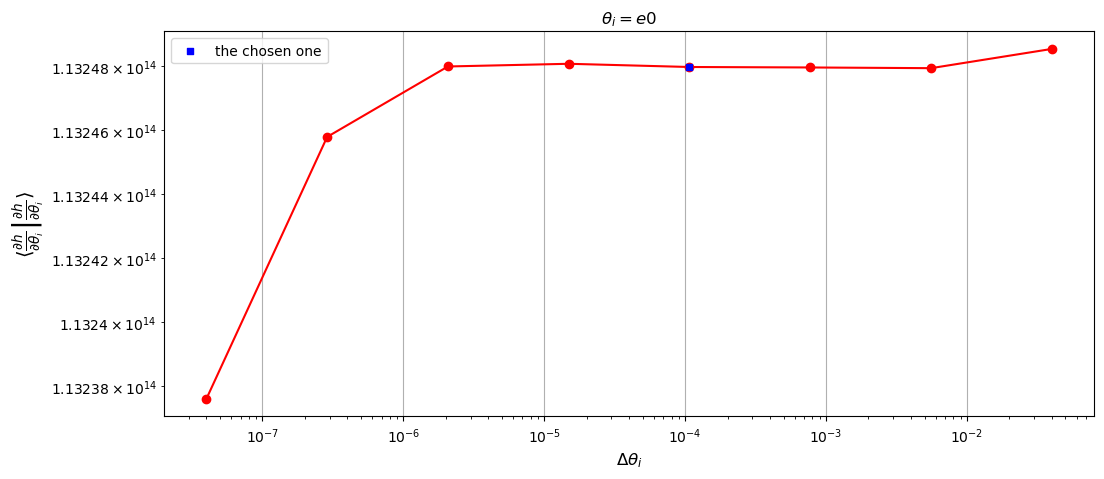

Gamma_ii for qS: 904937.0363384642
Gamma_ii for qS: 873883.9373395183
Gamma_ii for qS: 874455.8650289205
Gamma_ii for qS: 874539.4227431319
Gamma_ii for qS: 874526.609583195
Gamma_ii for qS: 874523.9554297313
Gamma_ii for qS: 874522.3185935838
Gamma_ii for qS: 874569.3567689044
[np.float64(0.035534580362565085), np.float64(0.0006540383709167715), np.float64(9.554482283864712e-05), np.float64(1.4651538096741777e-05), np.float64(3.0349694221461458e-06), np.float64(1.871691679807869e-06), np.float64(5.3784385373830746e-05)]
5


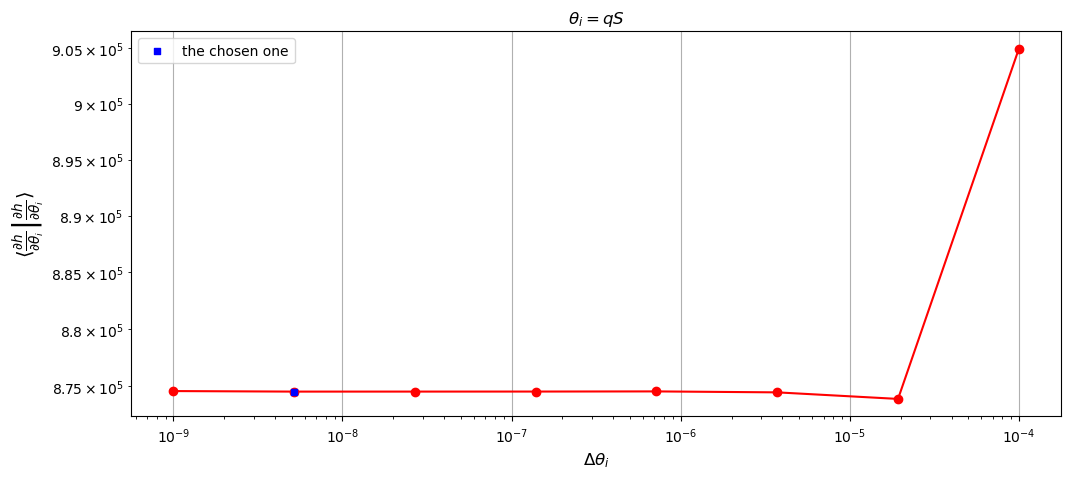

Gamma_ii for phiS: 595961.6257549557
Gamma_ii for phiS: 596021.4141940501
Gamma_ii for phiS: 596407.3198959742
Gamma_ii for phiS: 596424.2367925128
Gamma_ii for phiS: 596398.1283857675
Gamma_ii for phiS: 596402.2686669332
Gamma_ii for phiS: 596408.0939092966
Gamma_ii for phiS: 596393.4529747299
[np.float64(0.00010031256876111593), np.float64(0.0006470505794453115), np.float64(2.836386500581003e-05), np.float64(4.3776808649666586e-05), np.float64(6.942094930274907e-06), np.float64(9.767208766734226e-06), np.float64(2.454912020511114e-05)]
4


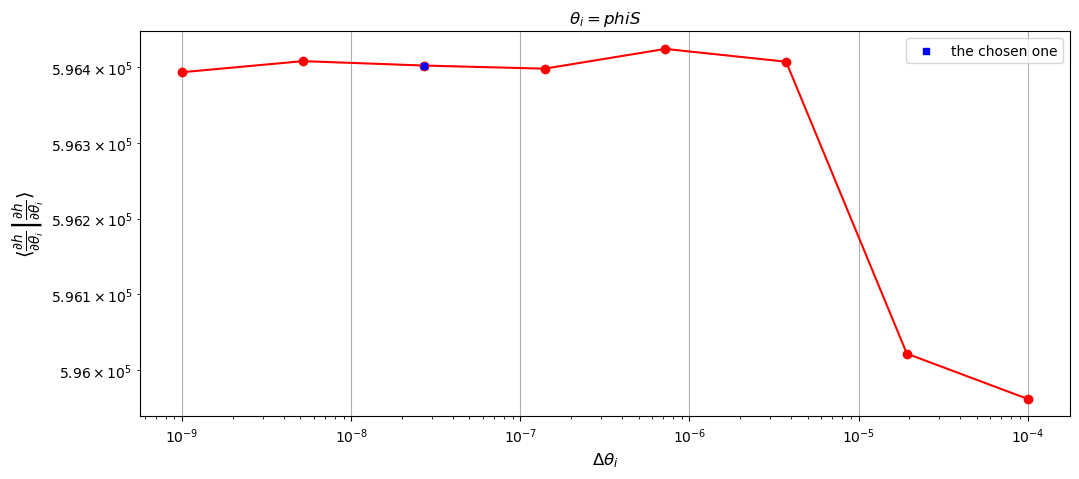

Gamma_ii for qK: 289774.6577811572
Gamma_ii for qK: 289774.65777756314
Gamma_ii for qK: 289774.65780031844
Gamma_ii for qK: 289774.65791564924
Gamma_ii for qK: 289774.6575598693
Gamma_ii for qK: 289774.65842156456
Gamma_ii for qK: 289774.64298836596
Gamma_ii for qK: 289774.6021958445
[np.float64(1.2402851411046774e-11), np.float64(7.852755543435085e-11), np.float64(3.980016662546344e-10), np.float64(1.2277814527925635e-09), np.float64(2.973673660134643e-09), np.float64(5.325931364659624e-08), np.float64(1.407732807825294e-07)]
0


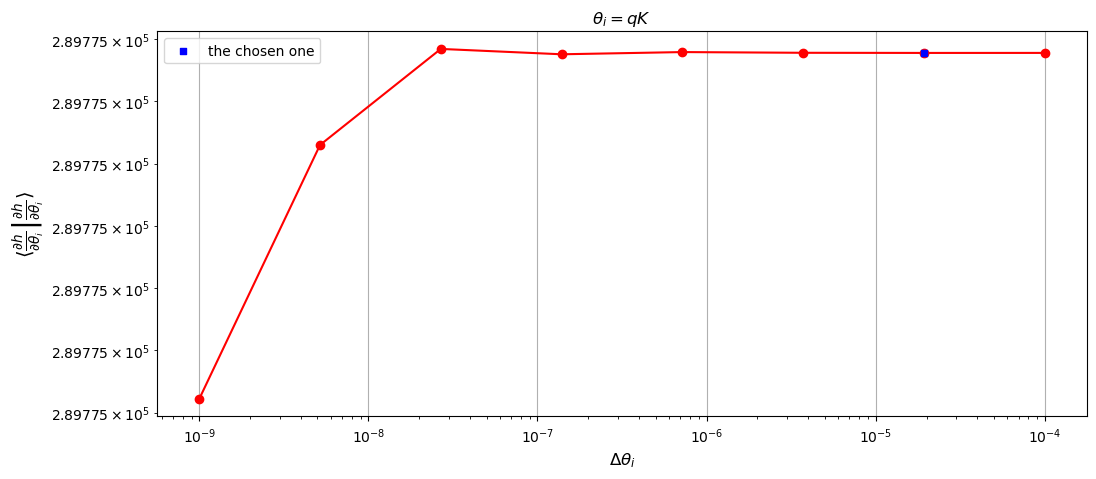

Gamma_ii for phiK: 121446.55087210733
Gamma_ii for phiK: 121446.5508726303
Gamma_ii for phiK: 121446.55086334025
Gamma_ii for phiK: 121446.55090801275
Gamma_ii for phiK: 121446.55113516758
Gamma_ii for phiK: 121446.55098744243
Gamma_ii for phiK: 121446.5603235267
Gamma_ii for phiK: 121446.54266789072
[np.float64(4.306147236948052e-12), np.float64(7.64949229035724e-11), np.float64(3.6783673327913664e-10), np.float64(1.870409880452627e-09), np.float64(1.216379952099155e-09), np.float64(7.687401148352414e-08), np.float64(1.453778394373238e-07)]
0


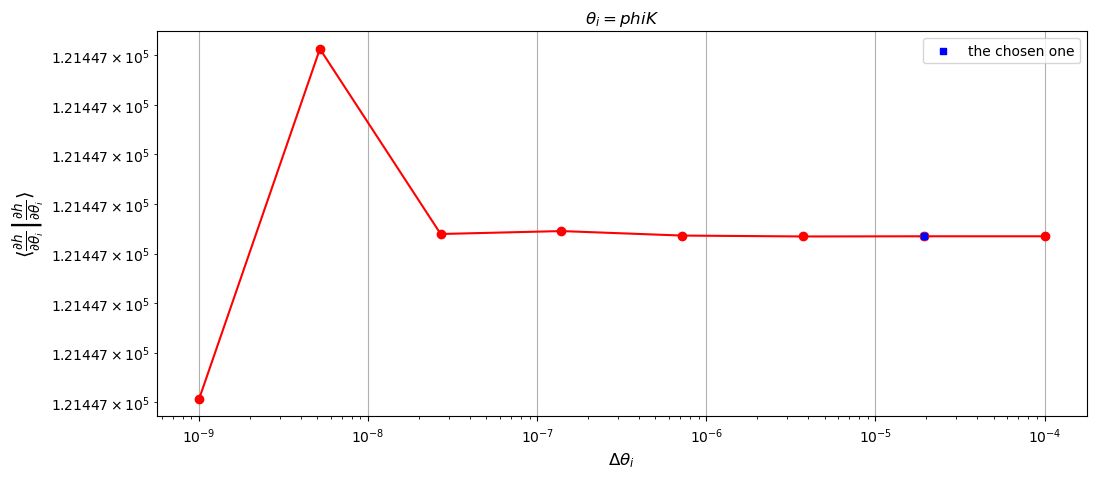

stable deltas: {'m1': 3.72759372031494, 'm2': 0.003727593720314938, 'p0': 0.000683701389351095, 'e0': 0.00010730783181118912, 'dist': 0.0, 'qS': 5.179474679231223e-09, 'phiS': 2.682695795279727e-08, 'qK': 1.9306977288832496e-05, 'phiK': 1.9306977288832496e-05, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 46.58722710609436 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 3.5535213947296143 seconds


In [5]:
m1 = 1e6
m2 = 1e1
a = 0.
p0 = 9.5
e0 = 0.4
xI0 = 1.0
dist = 0.1
qS = np.pi/3
phiS = np.pi/4
qK = np.pi/6
phiK = np.pi/8
Phi_phi0 = 1.0
Phi_theta0 = 0.0
Phi_r0 = 0.0

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
wave_params = dict(
    m1=m1,
    m2=m2,
    a=a,
    p0=p0,
    e0=e0,
    xI0=xI0,
    dist=dist,
    qS=qS,
    phiS=phiS,
    qK=qK,
    phiK=phiK,
    Phi_phi0=Phi_phi0,
    Phi_theta0=Phi_theta0,
    Phi_r0=Phi_r0
)

param_names = ['m1','m2','p0','e0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']

der_order = 4
Ndelta = 8
stability_plot = True

delta_range = dict(
    m1 = np.geomspace(1e-4*m1, 1e-9*m1, Ndelta),
    m2 = np.geomspace(1e-2*m2, 1e-7*m2, Ndelta),
    p0 = np.geomspace(1e-2*p0, 1e-7*p0, Ndelta),
    e0 = np.geomspace(1e-1*e0, 1e-7*e0, Ndelta),
    qS = np.geomspace(1e-4,    1e-9,    Ndelta),
    phiS = np.geomspace(1e-4,    1e-9,    Ndelta),
    qK = np.geomspace(1e-4,    1e-9,    Ndelta),
    phiK = np.geomspace(1e-4,    1e-9,    Ndelta),
)

Fisher = sef(wave_params=wave_params, param_names = param_names, 
             der_order = der_order, 
             Ndelta = Ndelta, 
             stability_plot = stability_plot,
             delta_range = delta_range,
            live_dangerously = False)

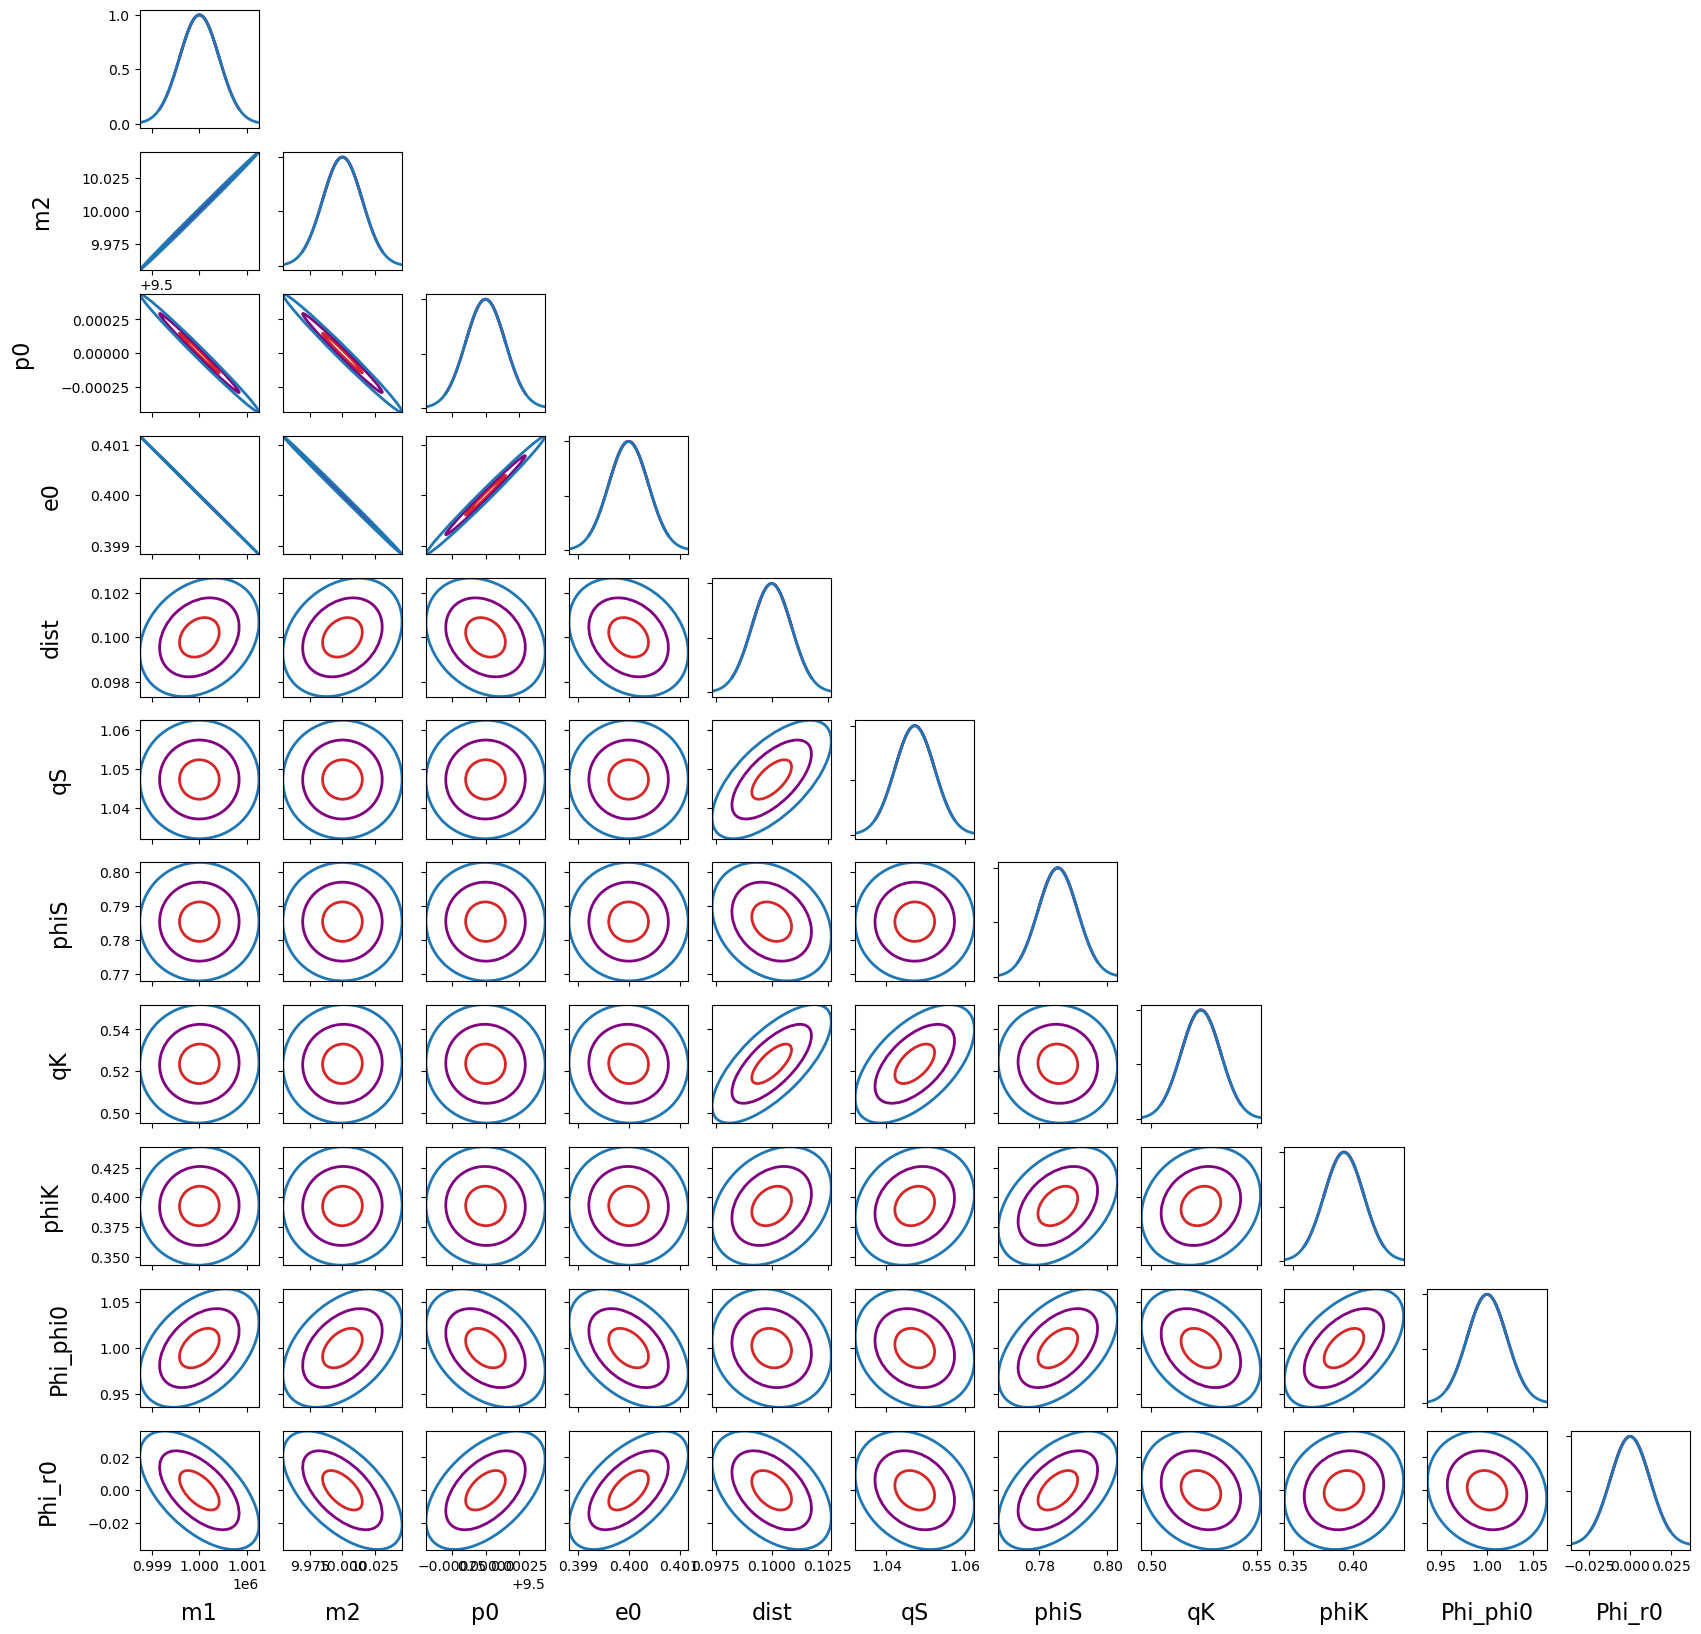

In [13]:
from stableemrifisher.plot import CovEllipsePlot

covariance = np.linalg.inv(Fisher)

fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))

ellipse_kwargs = dict(facecolor='None', edgecolor='tab:red', lw=2, n_std=1)
line_kwargs = dict(lw=2, color='tab:red')
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)

ellipse_kwargs = dict(facecolor='None', edgecolor='purple', lw=2, n_std=2)
line_kwargs = dict(lw=2, color='purple')
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)

ellipse_kwargs = dict(facecolor='None', edgecolor='tab:blue', lw=2, n_std=3)
line_kwargs = dict(lw=2, color='tab:blue')
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)

